In [ ]:
!git clone https://github.com/pjsun2012/Phase5_Capstone-Project.git

In [ ]:
!pip install fastai

##imorting the necessary libraries

In [3]:
from fastai.vision.all import *


## Define data path

Set the path to the dataset, which is 'Phase5_Capstone-Project/data', containing the 'CORROSION' and 'NOCORROSION' subfolders.


In [4]:
path = Path('Data/data')

## Prepare data with DataLoaders
**bold text**
Load the images from the 'CORROSION' and 'NOCORROSION' folders, apply appropriate data augmentations and transformations (e.g., resizing, normalization), and create `DataLoaders` for training and validation.


DataLoaders created with training and validation sets.
Number of training items: 1456
Number of validation items: 363


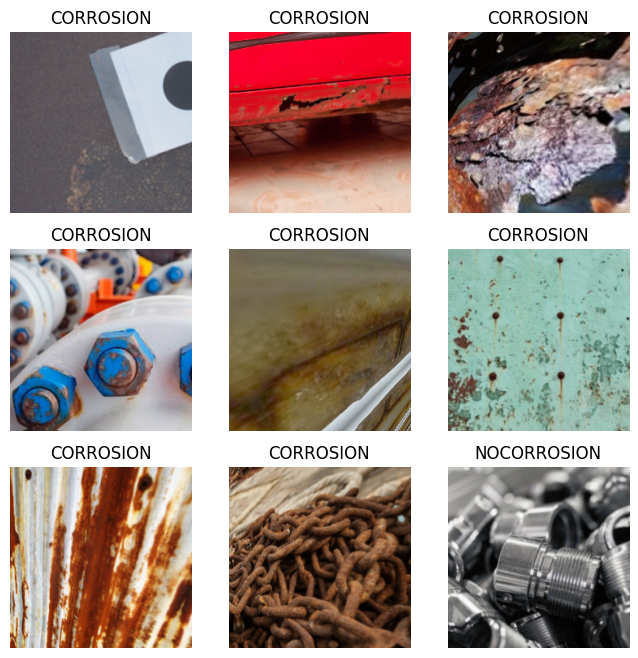

In [5]:
size = 224
bs = 32

dls = ImageDataLoaders.from_folder(path, valid_pct=0.2, seed=42,
    item_tfms=Resize(size),
    batch_tfms=aug_transforms(mult=2) + [Normalize.from_stats(*imagenet_stats)],
    bs=bs)

print("DataLoaders created with training and validation sets.")
print(f"Number of training items: {len(dls.train_ds)}")
print(f"Number of validation items: {len(dls.valid_ds)}")

dls.show_batch(max_n=9, figsize=(8,8))

## Initialize Learner with ResNet34

Create a `cnn_learner` using the prepared `DataLoaders`, the `resnet34` architecture as the backbone, and define metrics as `accuracy` for evaluating the model's performance.


In [7]:
learn = vision_learner(dls, resnet34, metrics=accuracy)
print("Learner initialized with resnet34 and accuracy metric.")

Learner initialized with resnet34 and accuracy metric.


In [8]:
learn.fine_tune(4)
print("Model training completed for 4 epochs.")

epoch,train_loss,valid_loss,accuracy,time
0,0.593704,0.269474,0.925620,06:18


epoch,train_loss,valid_loss,accuracy,time
0,0.286005,0.204621,0.939394,09:25
1,0.248296,0.220989,0.942149,09:19
2,0.170603,0.123218,0.958678,09:11
3,0.111802,0.124969,0.961433,08:56


Model training completed for 4 epochs.


Initial Epoch (before fine-tuning):
So there was this initial epoch (0) where the train_loss hit 0.593704 and valid_loss was 0.269474, with accuracy at 0.925620 (92.56%). That's basically what the model looked like before we ran the fine_tune method to adjust learning rates and unfreeze layers.

Fine-tuning Epochs (0-3):

Losses: The train_loss and valid_loss both dropped pretty consistently over those 4 epochs. Train_loss went from 0.286 down to 0.112, and valid_loss fell from 0.204 to 0.125. So the model was definitely learning and getting better at fitting both the training data and the validation data.

Accuracy: Validation accuracy climbed steadily — started at 93.94% in the first epoch and ended up at 96.14% by epoch 4. That's a solid improvement, and it shows the model's actually getting better at classifying the corrosion images.

Generalization: The valid_loss and train_loss stayed pretty close to each other throughout, which is a good sign that the model wasn't overfitting. There was a slight uptick in valid_loss at epoch 3 compared to epoch 2 (0.124969 vs 0.123218) while train_loss kept dropping — that's something to keep an eye on — but overall the trend looks really good.

Time: Each epoch took around 9 minutes to run.

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

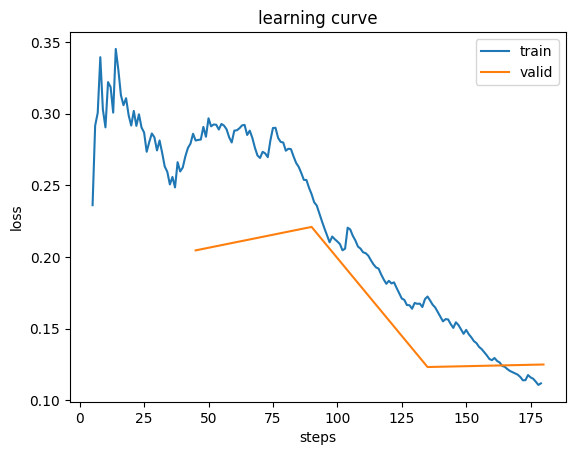

In [9]:
learn.recorder.plot_loss()

The plot above visualizes the training and validation loss over the epochs. To see the specific metrics for each epoch, including accuracy, we can display the recorded metrics directly.